# **PREPARAÇÃO DE DADOS**

# Considerações iniciais



LOrem

## Tratamento de PARTICIPANTES_2024

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [139]:
ano = 2021

In [140]:
if ano == 2024:
    arquivo_participantes = Path('../data/data_raw') / 'PARTICIPANTES_2024.csv'
    
    df_participantes_raw = pd.read_csv(arquivo_participantes, sep=';', encoding='latin-1')
    df_participantes = df_participantes_raw[['IN_TREINEIRO', 'SG_UF_PROVA', 'Q007', 'NO_MUNICIPIO_PROVA']]
    df_participantes = df_participantes.rename(columns={'Q007': 'Q006'})

    arquivo_resultados = Path('../data/data_raw') / 'RESULTADOS_2024.csv'
    
    df_resultado_raw = pd.read_csv(arquivo_resultados, sep=';', encoding='latin-1')
    df_resultado = df_resultado_raw[['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO' ]]

    
else: 
    arquivo_microdados = Path('../data/data_raw') / f'MICRODADOS_ENEM_{ano}.csv'
    df_microdados = pd.read_csv(arquivo_microdados, sep=';', encoding='latin-1')

    df_participantes = df_microdados[['IN_TREINEIRO', 'SG_UF_PROVA', 'Q006', 'NO_MUNICIPIO_PROVA']]
    df_resultado = df_microdados[['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO' ]]

df_participantes = df_participantes.rename(columns={'NO_MUNICIPIO_PROVA': 'MUNICIPIO'})
df_resultado = df_resultado.rename(columns={'NO_MUNICIPIO_PROVA': 'MUNICIPIO'})

In [141]:
df_participantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 3389832 entries, 0 to 3389831
Data columns (total 4 columns):
 #   Column        Dtype
---  ------        -----
 0   IN_TREINEIRO  int64
 1   SG_UF_PROVA   str  
 2   Q006          str  
 3   MUNICIPIO     str  
dtypes: int64(1), str(3)
memory usage: 103.4 MB


In [142]:
df_participantes.head()

,IN_TREINEIRO,SG_UF_PROVA,Q006,MUNICIPIO
0,0,MG,D,Nova Lima
1,0,AL,B,Maceió
2,0,SP,C,Ferraz de Vasconcelos
3,0,CE,B,Crato
4,0,CE,C,Acarape


In [143]:
df_participantes.isnull().mean()*100

IN_TREINEIRO    0.000000
SG_UF_PROVA     0.000000
Q006            0.000059
MUNICIPIO       0.000000
dtype: float64

In [144]:
cor_renda_map_sm = {
    "A": 0.0,
    "B": 1.0,
    "C": 1.5,
    "D": 2.0,
    "E": 2.5,
    "F": 3.0,
    "G": 4.0,
    "H": 5.0,
    "I": 6.0,
    "J": 7.0,
    "K": 8.0,
    "L": 9.0,
    "M": 10.0,
    "N": 12.0,
    "O": 15.0,
    "P": 20.0,
    "Q": 20.0
}

df_participantes['Q006'] = df_participantes['Q006'].map(cor_renda_map_sm)
df_participantes['Q006'] = df_participantes['Q006'].astype("float64")
df_participantes = df_participantes.rename(columns={'Q006': 'RENDA_FAMILIAR_SM'})

In [145]:
if 'RENDA_FAMILIAR_SM' in df_participantes.columns:
    if not np.issubdtype(df_participantes['RENDA_FAMILIAR_SM'].dropna().dtype, np.number):
        df_participantes['RENDA_FAMILIAR_SM'] = df_participantes['RENDA_FAMILIAR_SM'].map(cor_renda_map_sm)

    media_q006_por_uf = df_participantes.groupby('SG_UF_PROVA')['RENDA_FAMILIAR_SM'].transform('mean')
    df_participantes['RENDA_FAMILIAR_SM'] = df_participantes['RENDA_FAMILIAR_SM'].fillna(media_q006_por_uf)

    df_participantes['RENDA_FAMILIAR_SM'] = df_participantes['RENDA_FAMILIAR_SM'].fillna(df_participantes['RENDA_FAMILIAR_SM'].mean())

In [146]:
df_participantes.isnull().sum()*100

IN_TREINEIRO         0
SG_UF_PROVA          0
RENDA_FAMILIAR_SM    0
MUNICIPIO            0
dtype: int64

In [147]:
df_participantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 3389832 entries, 0 to 3389831
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   IN_TREINEIRO       int64  
 1   SG_UF_PROVA        str    
 2   RENDA_FAMILIAR_SM  float64
 3   MUNICIPIO          str    
dtypes: float64(1), int64(1), str(2)
memory usage: 103.4 MB


In [148]:
df_participantes = df_participantes[df_participantes['IN_TREINEIRO'] != 1]
df_participantes = df_participantes.drop(columns=['IN_TREINEIRO'])

In [149]:
df_participantes['MUNICIPIO'] = df_participantes['MUNICIPIO'].str.upper()

In [150]:
df_participantes.info()

<class 'pandas.DataFrame'>
Index: 2952642 entries, 0 to 3389831
Data columns (total 3 columns):
 #   Column             Dtype  
---  ------             -----  
 0   SG_UF_PROVA        str    
 1   RENDA_FAMILIAR_SM  float64
 2   MUNICIPIO          str    
dtypes: float64(1), str(2)
memory usage: 90.1 MB


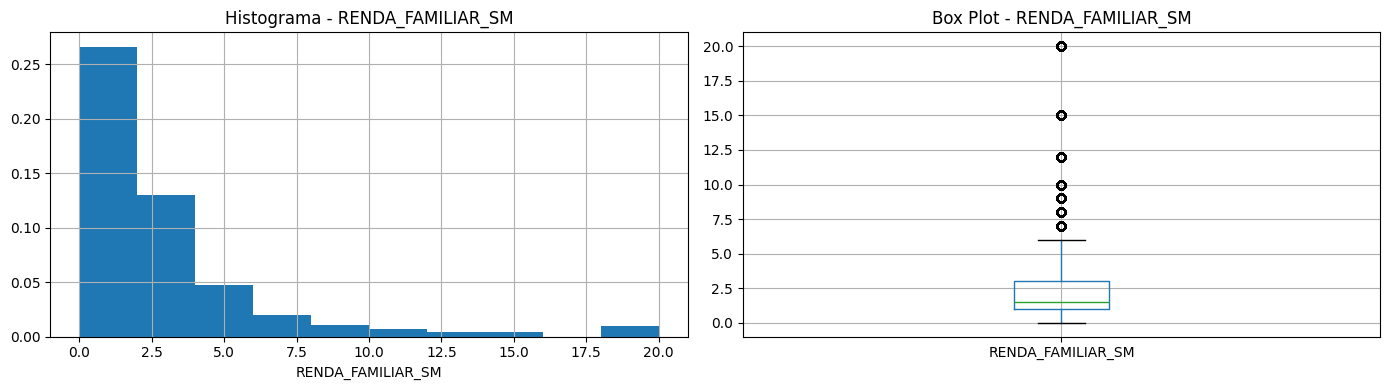

In [151]:
analise_cols = ['RENDA_FAMILIAR_SM']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_participantes[col].hist(ax=ax1, density=True)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_participantes.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

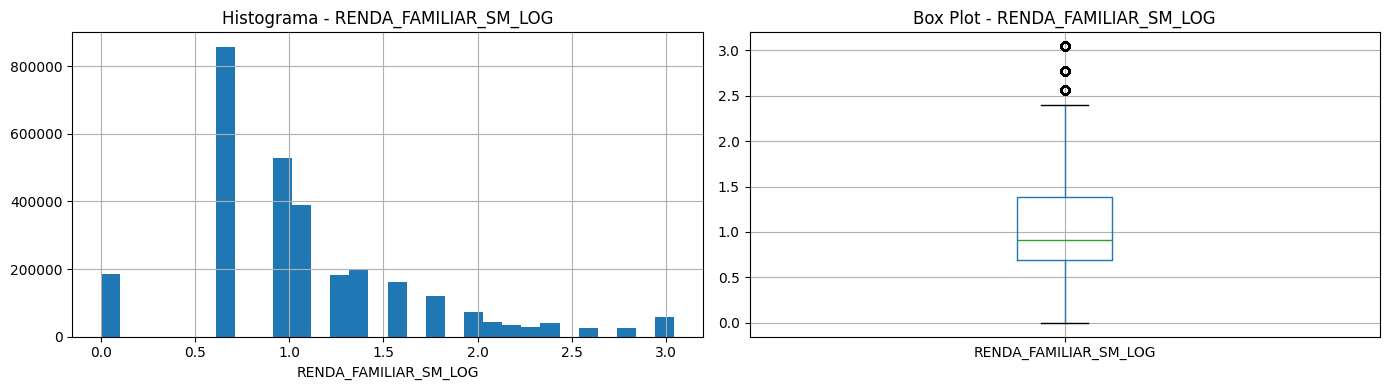

In [152]:
df_participantes['RENDA_FAMILIAR_SM_LOG'] = np.log1p(df_participantes['RENDA_FAMILIAR_SM'])

analise_cols = ['RENDA_FAMILIAR_SM_LOG']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_participantes[col].hist(ax=ax1, bins=30)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_participantes.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

In [153]:
analise_renda = ['RENDA_FAMILIAR_SM_LOG']

df_tratamento_outlier = df_participantes.copy()

valores_q1 = [0.25, 0.2, 0.15, 0.1, 0.05]
valores_q3 = [0.75, 0.8, 0.85, 0.9, 0.95]

for col in analise_renda:
    for q1_val, q3_val in zip(valores_q1, valores_q3):
        
        df_col_filtrado = df_tratamento_outlier.copy()
        
        Q1 = df_tratamento_outlier[col].quantile(q1_val)
        Q3 = df_tratamento_outlier[col].quantile(q3_val)
        IQR = Q3 - Q1
        
        df_col_filtrado = df_col_filtrado[
            (df_col_filtrado[col] >= Q1 - 1.5 * IQR) & 
            (df_col_filtrado[col] <= Q3 + 1.5 * IQR)
        ]
        
        proporcao_removida = (
            (df_tratamento_outlier.shape[0] - df_col_filtrado.shape[0]) 
            / df_tratamento_outlier.shape[0]
        ) * 100
        
        print(f'Coluna {col} | Q1={q1_val}, Q3={q3_val} → {proporcao_removida:.2f}% removidos')
        
        if proporcao_removida <= 5:
            print('Usando esse corte\n')
            df_tratamento_outlier = df_col_filtrado.copy()
            break
    else:
        print(f'Nenhum corte adequado para {col} — mantendo dados originais\n')

df_participantes = df_tratamento_outlier.copy()
df_participantes = df_participantes.drop(columns=['RENDA_FAMILIAR_SM_LOG'])

Coluna RENDA_FAMILIAR_SM_LOG | Q1=0.25, Q3=0.75 → 3.73% removidos
Usando esse corte



In [154]:
df_municipio = df_participantes.groupby('MUNICIPIO').agg(
    RENDA_FAMILIAR_SM_MEDIA=('RENDA_FAMILIAR_SM', 'mean')
).reset_index()

In [155]:
df_municipio.head()

,MUNICIPIO,RENDA_FAMILIAR_SM_MEDIA
0,ABAETETUBA,1.375830
1,ABAETÉ,2.293199
2,ABREU E LIMA,1.576721
3,ACARAPE,1.199248
4,ACARAÚ,0.980366


## Tratamento Resultados

In [156]:
df_resultado.head()

,SG_UF_PROVA,MUNICIPIO,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,MG,Nova Lima,0,1,1,0,NaN,574.6,472.6,NaN,760.0
1,AL,Maceió,1,1,1,1,505.9,551.8,498.3,461.5,560.0
2,SP,Ferraz de Vasconcelos,0,0,0,0,NaN,NaN,NaN,NaN,NaN
3,CE,Crato,1,1,1,1,580.7,678.9,638.9,659.5,780.0
4,CE,Acarape,1,1,1,1,497.7,532.4,457.6,582.6,780.0


In [157]:
df_resultado.isnull().mean()*100

SG_UF_PROVA         0.000000
MUNICIPIO           0.000000
TP_PRESENCA_CN      0.000000
TP_PRESENCA_CH      0.000000
TP_PRESENCA_LC      0.000000
TP_PRESENCA_MT      0.000000
NU_NOTA_CN         33.747631
NU_NOTA_CH         29.837850
NU_NOTA_LC         29.837850
NU_NOTA_MT         33.747631
NU_NOTA_REDACAO    29.837850
dtype: float64

In [158]:
df_resultado = df_resultado[df_resultado['TP_PRESENCA_CN'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_CH'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_LC'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_MT'] == 1]

df_resultado = df_resultado.drop(columns=['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT'])

In [159]:
df_resultado.isnull().mean()*100

SG_UF_PROVA        0.0
MUNICIPIO          0.0
NU_NOTA_CN         0.0
NU_NOTA_CH         0.0
NU_NOTA_LC         0.0
NU_NOTA_MT         0.0
NU_NOTA_REDACAO    0.0
dtype: float64

In [160]:
df_resultado['MUNICIPIO'] = df_resultado['MUNICIPIO'].str.upper()

In [161]:
df_resultado.head()

,SG_UF_PROVA,MUNICIPIO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
1,AL,MACEIÓ,505.9,551.8,498.3,461.5,560.0
3,CE,CRATO,580.7,678.9,638.9,659.5,780.0
4,CE,ACARAPE,497.7,532.4,457.6,582.6,780.0
8,MG,BELO HORIZONTE,487.4,476.5,450.7,493.4,520.0
9,BA,RUY BARBOSA,507.6,539.2,494.6,413.3,380.0


In [162]:
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

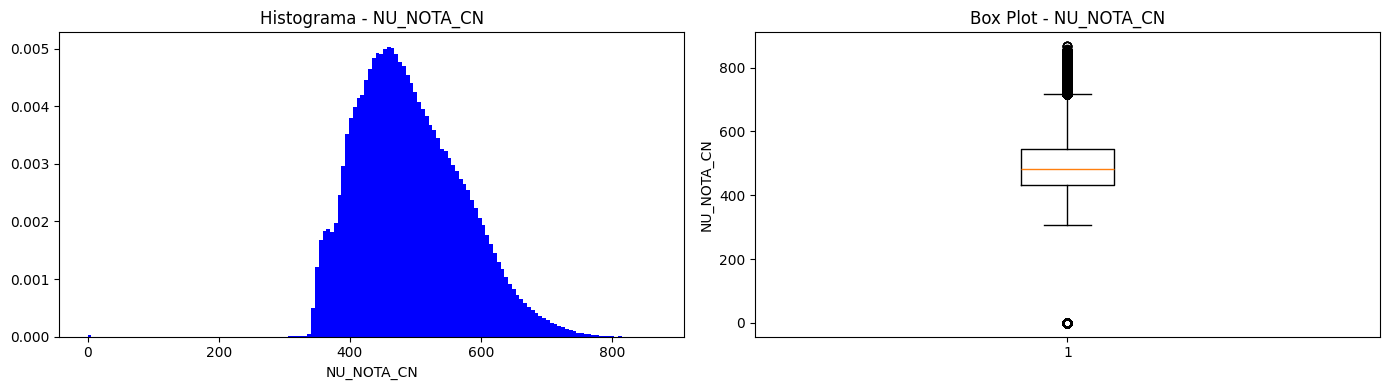

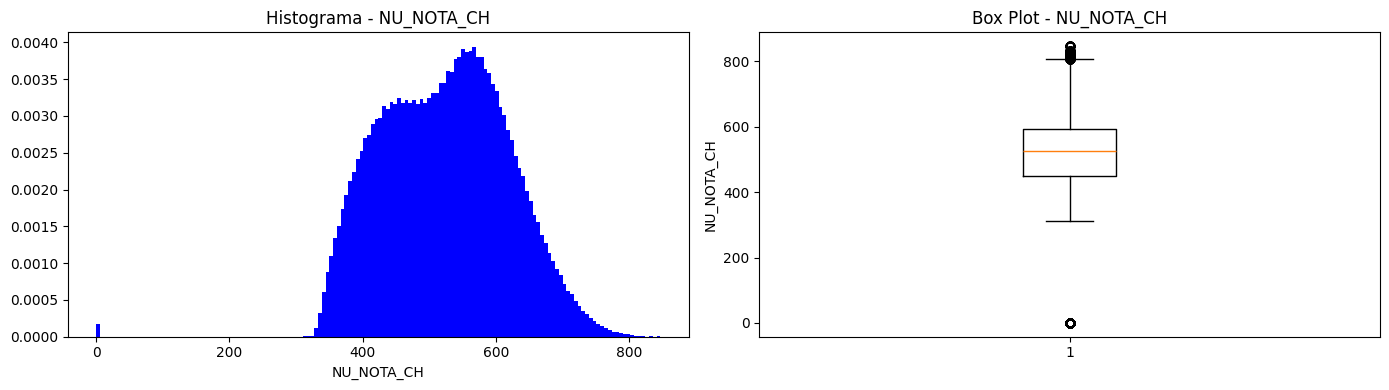

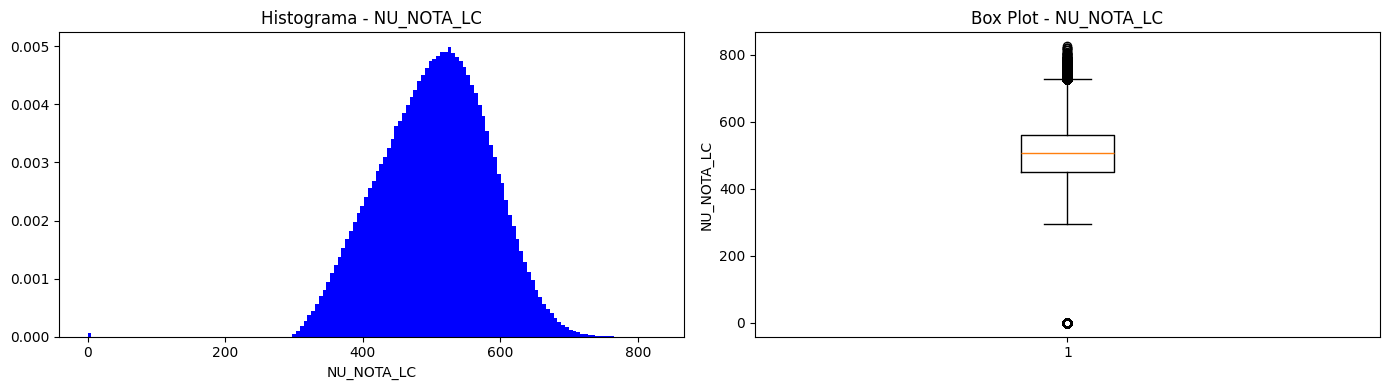

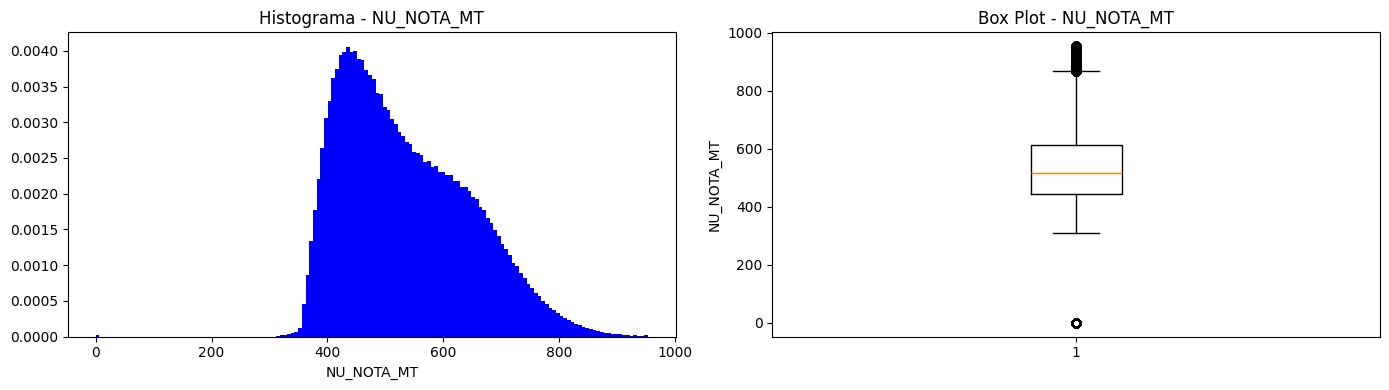

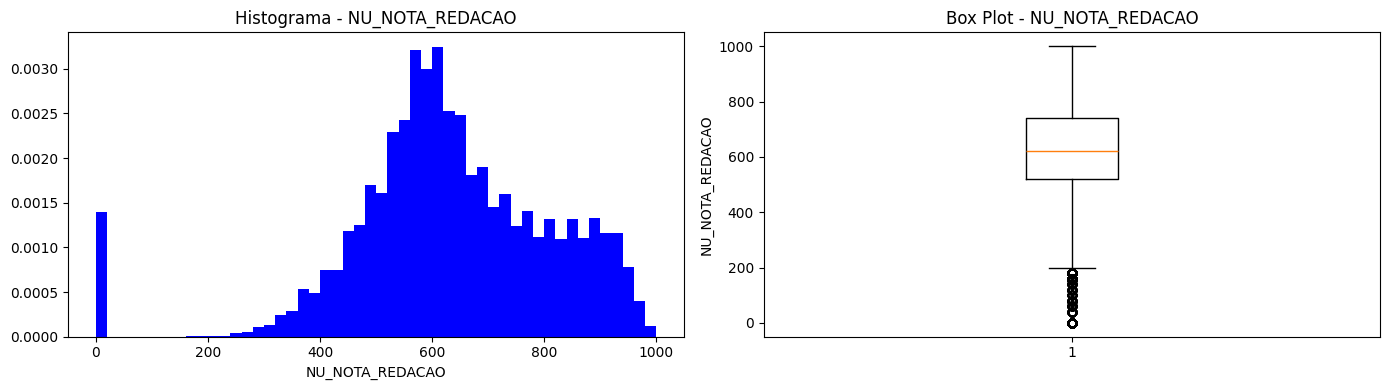

In [163]:
for col in colunas_notas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    if col == 'NU_NOTA_REDACAO':
        ax1.hist(df_resultado[col].dropna(), bins=50, density=True, color='blue')
    else:
        ax1.hist(df_resultado[col].dropna(), bins=150, density=True, color='blue')
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)

    ax2.boxplot(df_resultado[col].dropna(), vert=True)
    ax2.set_title(f'Box Plot - {col}')
    ax2.set_ylabel(col)

    plt.tight_layout()
    plt.show()


In [164]:
df_tratamento_outlier = df_resultado.copy()

valores_q1 = [0.25, 0.2, 0.15, 0.1, 0.05]
valores_q3 = [0.75, 0.8, 0.85, 0.9, 0.95]

n_original = df_resultado.shape[0]

for q1_val, q3_val in zip(valores_q1, valores_q3):
    
    df_temp = df_resultado.copy()
    
    for col in colunas_notas:
        Q1 = df_resultado[col].quantile(q1_val)
        Q3 = df_resultado[col].quantile(q3_val)
        IQR = Q3 - Q1
        
        df_temp = df_temp[
            (df_temp[col] >= Q1 - 1.5 * IQR) & 
            (df_temp[col] <= Q3 + 1.5 * IQR)
        ]
    
    proporcao_total = (
        (n_original - df_temp.shape[0]) / n_original
    ) * 100
    
    print(f'Q1={q1_val}, Q3={q3_val} → TOTAL {proporcao_total:.2f}% removidos')
    
    if proporcao_total <= 5:
        print('→ Corte global aceito\n')
        df_tratamento_outlier = df_temp.copy()
        break
else:
    print('→ Nenhum corte global válido — mantendo dados')

print(f'\nTotal removido final: {((n_original - df_tratamento_outlier.shape[0]) / n_original) * 100:.2f}%')

df_resultado = df_tratamento_outlier.copy()

Q1=0.25, Q3=0.75 → TOTAL 3.69% removidos
→ Corte global aceito


Total removido final: 3.69%


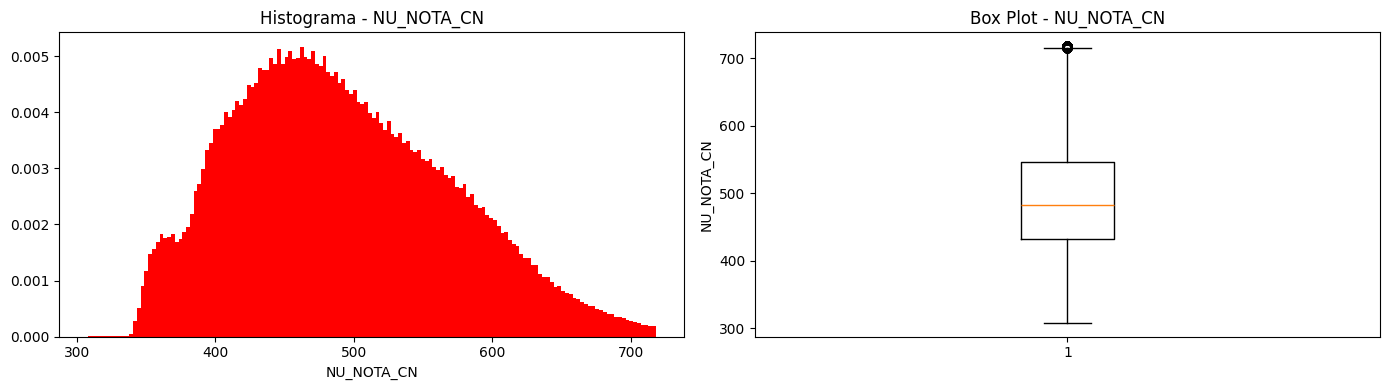

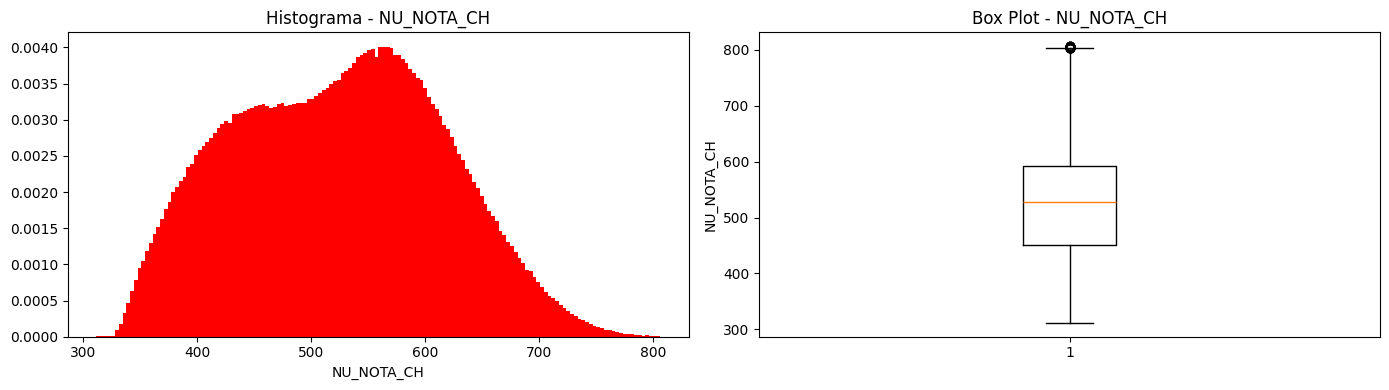

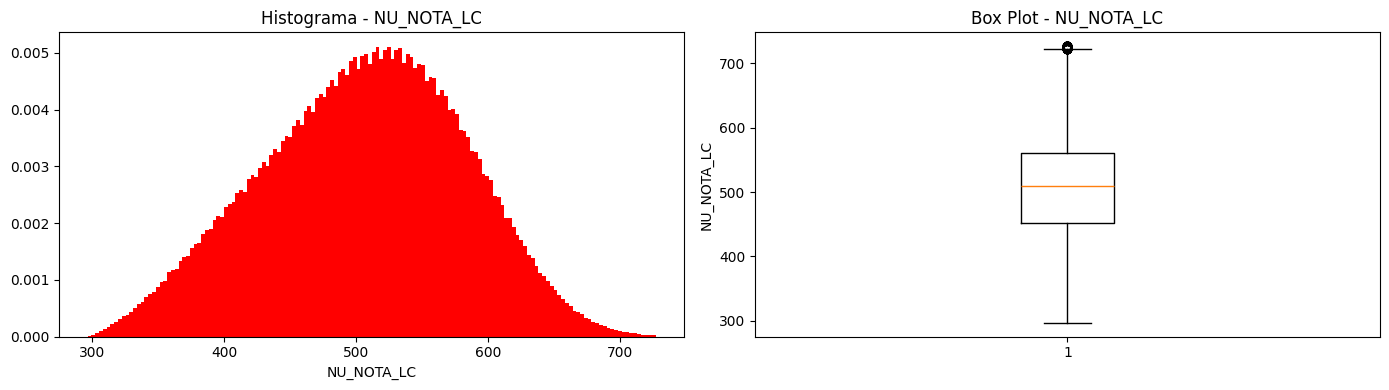

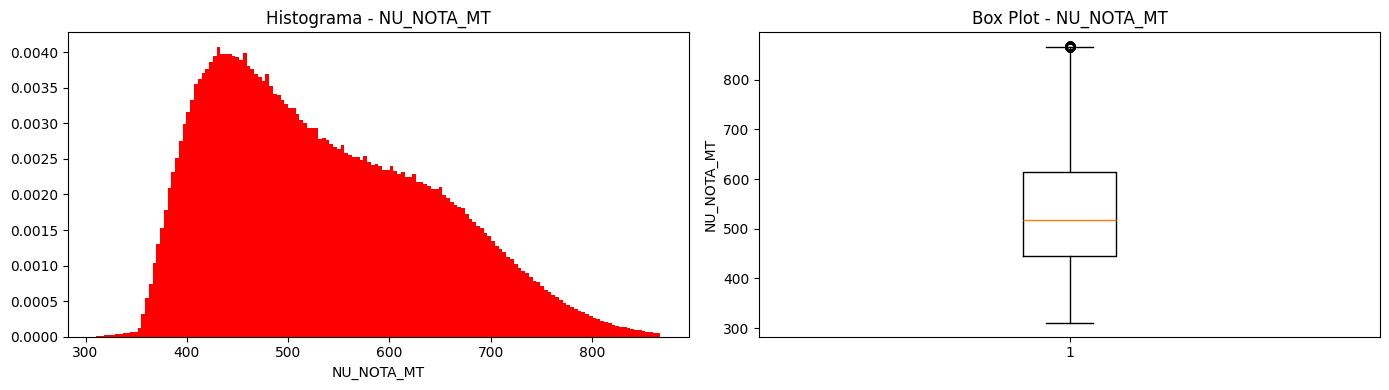

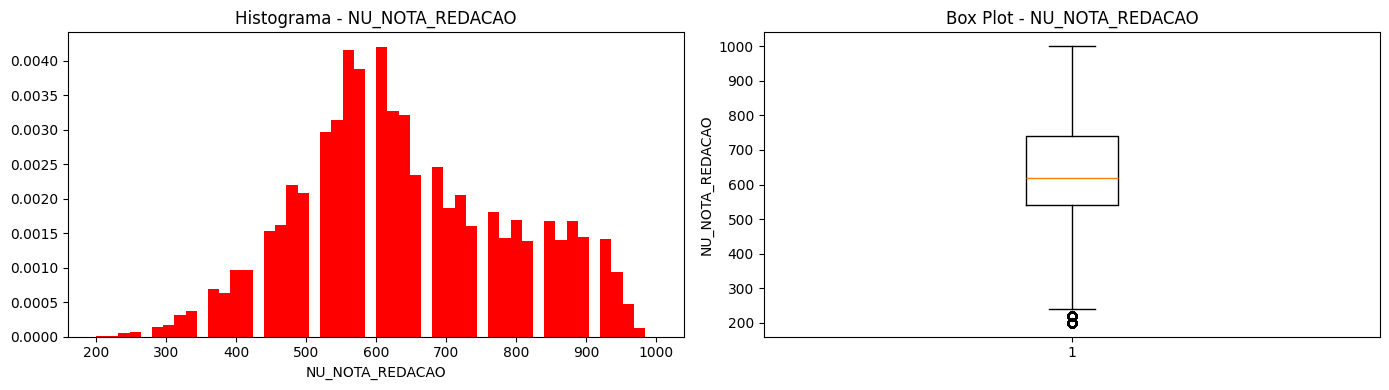

In [165]:
for col in colunas_notas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    if col == 'NU_NOTA_REDACAO':
        ax1.hist(df_resultado[col].dropna(), bins=50, density=True, color='red')
    else:
        ax1.hist(df_resultado[col].dropna(), bins=150, density=True, color='red')
    
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)

    ax2.boxplot(df_resultado[col].dropna(), vert=True)
    ax2.set_title(f'Box Plot - {col}')
    ax2.set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [166]:
df_resultado.head()

,SG_UF_PROVA,MUNICIPIO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
1,AL,MACEIÓ,505.9,551.8,498.3,461.5,560.0
3,CE,CRATO,580.7,678.9,638.9,659.5,780.0
4,CE,ACARAPE,497.7,532.4,457.6,582.6,780.0
8,MG,BELO HORIZONTE,487.4,476.5,450.7,493.4,520.0
9,BA,RUY BARBOSA,507.6,539.2,494.6,413.3,380.0


In [167]:
df_resultado = df_resultado.groupby('MUNICIPIO').agg(
    UF=('SG_UF_PROVA', 'first'),
    QTD_PARTICIPANTES=('MUNICIPIO', 'size'),
    NOTA_CN_MEDIA=('NU_NOTA_CN', 'mean'),
    NOTA_CH_MEDIA=('NU_NOTA_CH', 'mean'),
    NOTA_LC_MEDIA=('NU_NOTA_LC', 'mean'),
    NOTA_MT_MEDIA=('NU_NOTA_MT', 'mean'),
    NOTA_REDACAO_MEDIA=('NU_NOTA_REDACAO', 'mean')
).reset_index()

df_resultado['MEDIA_GERAL'] = df_resultado[['NOTA_CN_MEDIA', 'NOTA_CH_MEDIA', 'NOTA_LC_MEDIA', 'NOTA_MT_MEDIA', 'NOTA_REDACAO_MEDIA']].mean(axis=1)  

In [168]:
df_municipio_clustering = df_resultado.merge(
    df_municipio,
    on='MUNICIPIO',
    how='left'
)

X_scaled_municipio = df_municipio_clustering.copy()

X_scaled_municipio = X_scaled_municipio.drop(columns=['MUNICIPIO', 'RENDA_FAMILIAR_SM_MEDIA', 'UF', 'QTD_PARTICIPANTES', 'MEDIA_GERAL'])

col_scatter = ['NOTA_CN_MEDIA', 'NOTA_CH_MEDIA', 'NOTA_LC_MEDIA', 'NOTA_MT_MEDIA', 'NOTA_REDACAO_MEDIA']
scaler = StandardScaler()
X_scaled_municipio[col_scatter] = scaler.fit_transform(X_scaled_municipio[col_scatter])


In [182]:
colunas_notas_media = ['NOTA_CN_MEDIA', 'NOTA_CH_MEDIA', 'NOTA_LC_MEDIA', 'NOTA_MT_MEDIA', 'NOTA_REDACAO_MEDIA', 'MEDIA_GERAL']

In [186]:
def media_ponderada(grupo, coluna, peso="QTD_PARTICIPANTES"):
    d = grupo[[coluna, peso]].dropna()
    soma_pesos = d[peso].sum()
    return (d[coluna] * d[peso]).sum() / soma_pesos if soma_pesos != 0 else pd.NA

df_estado_clustering = (
    df_municipio_clustering.groupby("UF")
    .apply(
        lambda g: pd.Series(
            {
                "QTD_PARTICIPANTES": g["QTD_PARTICIPANTES"].sum(),
                "RENDA_FAMILIAR_SM_MEDIA": g["RENDA_FAMILIAR_SM_MEDIA"].mean(),
                **{col: media_ponderada(g, col) for col in colunas_notas_media},
            }
        )
    )
    .reset_index()
    .sort_values("UF")
    .reset_index(drop=True)
)


X_scaled_estado = df_estado_clustering.copy()
X_scaled_estado = X_scaled_estado.drop(columns=['RENDA_FAMILIAR_SM_MEDIA', 'UF', 'QTD_PARTICIPANTES', 'MEDIA_GERAL'])
col_scatter = ['NOTA_CN_MEDIA', 'NOTA_CH_MEDIA', 'NOTA_LC_MEDIA', 'NOTA_MT_MEDIA', 'NOTA_REDACAO_MEDIA']
scaler = StandardScaler()
X_scaled_estado[col_scatter] = scaler.fit_transform(X_scaled_estado[col_scatter])

In [188]:
df_municipio_clustering.head()

,MUNICIPIO,UF,QTD_PARTICIPANTES,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA,MEDIA_GERAL,RENDA_FAMILIAR_SM_MEDIA
0,ABAETETUBA,PA,3260,461.429080,484.314601,462.841810,481.403773,624.785276,502.954908,1.375830
1,ABAETÉ,MG,466,499.301288,525.673820,511.850429,551.033476,660.557940,549.683391,2.293199
2,ABREU E LIMA,PE,1302,472.267972,499.226498,487.838786,501.579416,603.364055,512.855346,1.576721
3,ACARAPE,CE,296,462.516554,482.811486,472.802703,489.461149,614.054054,504.329189,1.199248
4,ACARAÚ,CE,865,459.577803,481.142775,480.484740,507.155723,631.283237,511.928855,0.980366


In [191]:
X_scaled_municipio.head()

,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA
0,-0.778894,-0.832012,-1.042022,-1.081596,0.178256
1,0.948819,0.702417,0.841065,1.041826,1.198837
2,-0.284429,-0.278780,-0.081548,-0.466321,-0.432883
3,-0.729284,-0.887778,-0.659289,-0.835879,-0.127901
4,-0.863349,-0.949687,-0.364117,-0.296267,0.363641


In [190]:
df_estado_clustering.head()

,UF,QTD_PARTICIPANTES,RENDA_FAMILIAR_SM_MEDIA,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA,MEDIA_GERAL
0,AC,12328.0,1.704609,470.478318,503.314406,486.900552,496.863546,606.685594,512.848483
1,AL,36477.0,1.486457,477.955109,506.487184,488.404545,518.476440,638.102914,525.885238
2,AM,41905.0,1.207839,462.690564,490.134645,475.850273,488.711454,576.426202,498.762628
3,AP,12822.0,1.545431,469.075121,501.103229,478.523483,493.003595,607.301513,509.801388
4,BA,170695.0,1.498240,480.485734,510.632578,492.468327,514.388792,629.481356,525.491357


In [192]:
X_scaled_estado.head()

,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA
0,-1.105791,-0.790711,-0.693032,-1.269922,-1.297394
1,-0.572388,-0.603158,-0.601218,-0.278031,0.407869
2,-1.661378,-1.569808,-1.367612,-1.644050,-2.939806
3,-1.205896,-0.921421,-1.204422,-1.447068,-1.263963
4,-0.391850,-0.358111,-0.353139,-0.465628,-0.060090
